# Logging the evolution

Set the `logfile` parameter to a path, and every call to `fit` will write:

| file | content |
|---|---|
| `<logfile>` | one row per generation: losses, sizes, stall count, archive size, number of evaluations, and the best expression |
| `<logfile>_islands.csv` | the same statistics, one row per island and generation |
| `<logfile>_simplifications.csv` | every replacement performed by the simplifiers (`original` → `replacement`) |
| `<logfile>_simplification_table` | the expressions stored by the inexact simplifier, at the end of the run (only with `inexact_simplification=True`) |
| `<logfile>_runs.jsonl` | one JSON object per run, with the seed and all parameters |

All files are valid CSV (expressions are quoted) and have a `run_id` column. Files are
opened in append mode, so fitting several times with the same `logfile` adds rows
instead of overwriting them. Brush refuses to append to a file that was written with
different columns (for example, by an older version).

In [ ]:
import os, shutil

import pandas as pd
import matplotlib.pyplot as plt

from pybrush import BrushRegressor

LOG_DIR = "logs"
shutil.rmtree(LOG_DIR, ignore_errors=True)
os.makedirs(LOG_DIR, exist_ok=True)

df = pd.read_csv("../examples/datasets/d_enc.csv")
X = df.drop(columns="label")
y = df["label"]

pd.set_option("display.max_colwidth", 100)

## Generating the log files

We fit three seeds and write all of them to the **same** `logfile`; the `run_id`
column tells the runs apart.

In [ ]:
LOGFILE = os.path.join(LOG_DIR, "brush.csv")
seeds = [0, 1, 2]
estimators = {}

for seed in seeds:
    est = BrushRegressor(
        functions=["Add", "Sub", "Mul", "Div", "Sin", "Cos", "Exp", "Logabs", "Sqrtabs"],
        max_gens=50,
        pop_size=100,
        num_islands=4,
        max_size=50,
        max_depth=6,
        objectives=["scorer", "linear_complexity"],
        inexact_simplification=True,
        logfile=LOGFILE, # This toggle on the generation of logfiles
        random_state=seed, # Brush has total random seed control
        verbosity=0,
    )
    est.fit(X, y)
    estimators[seed] = est

# Files were generated after fitting the estimator
sorted(os.listdir(LOG_DIR))

['brush.csv',
 'brush.csv_islands.csv',
 'brush.csv_runs.jsonl',
 'brush.csv_simplification_table',
 'brush.csv_simplifications.csv']

## Run metadata

`_runs.jsonl` has one line per call to `fit`, with the full set of parameters.

In [3]:
runs = pd.json_normalize(pd.read_json(LOGFILE + "_runs.jsonl", lines=True).to_dict("records"))
runs[["run_id", "random_state", "params.pop_size", "params.max_gens", "params.num_islands", "params.scorer"]]

,run_id,random_state,params.pop_size,params.max_gens,params.num_islands,params.scorer
0,20260923T121716.761-c517,0,100,50,4,mse
1,20260923T121720.173-a13f,1,100,50,4,mse
2,20260923T121723.647-be9d,2,100,50,4,mse


## The evolution log

Each row is one generation of one run. `best_*` refer to the best individual (chosen on
the validation partition), and `med_*`/`max_*` summarize the whole population.

`n_evaluations` is cumulative. Models that survived across generations are not
refitted thus not counted towards the number of evaluations.
The number of evaluations refers to the number of times a program was fitted 
(had it's weights optimized). It does not reflect the number of optimization
steps performed for each individual.

In [4]:
log = pd.read_csv(LOGFILE)

print("columns:", list(log.columns))
log.head()

columns: ['run_id', 'random_state', 'generation', 'time', 'best_score', 'best_score_val', 'med_score', 'med_score_val', 'med_size', 'med_complexity', 'max_size', 'max_complexity', 'best_size', 'best_complexity', 'stall_count', 'archive_size', 'n_evaluations', 'best_model']


,run_id,random_state,generation,time,best_score,best_score_val,med_score,med_score_val,med_size,med_complexity,max_size,max_complexity,best_size,best_complexity,stall_count,archive_size,n_evaluations,best_model
0,20260923T121716.761-c517,0,0,0.068071,10.350908,9.278577,71.704758,77.782562,7,32,39,37237,39,5225,0,5,400,"1.62*Add(0.32*Add(109.51*Div(109.30*x3,200.26*Add(225.90*x2,-788.44*Sqrtabs(-3332.07*x4))),31.95..."
1,20260923T121716.761-c517,0,1,0.126026,9.956403,9.127022,20.323715,21.707689,6,25,42,37237,39,5225,0,7,700,"1.62*Add(0.32*Add(67.72*Div(67.59*x3,302.11*Add(227.53*x2,-783.07*Sqrtabs(-3286.79*x4))),32.25*x..."
2,20260923T121716.761-c517,0,2,0.189985,9.936137,9.127022,17.851387,19.497444,7,27,45,8990,39,5225,1,7,1000,"1.62*Add(0.32*Add(67.72*Div(67.59*x3,302.11*Add(227.53*x2,-783.07*Sqrtabs(-3286.79*x4))),32.25*x..."
3,20260923T121716.761-c517,0,3,0.244779,9.934284,9.127022,15.598775,16.937330,13,95,45,8990,39,5225,2,9,1300,"1.62*Add(0.32*Add(67.72*Div(67.59*x3,302.11*Add(227.53*x2,-783.07*Sqrtabs(-3286.79*x4))),32.25*x..."
4,20260923T121716.761-c517,0,4,0.302656,9.932689,9.127022,15.123131,16.591620,13,107,43,8990,39,5225,3,10,1600,"1.62*Add(0.32*Add(67.72*Div(67.59*x3,302.11*Add(227.53*x2,-783.07*Sqrtabs(-3286.79*x4))),32.25*x..."


In [5]:
# number of generations, best metric and final expression of each run
summary = log.groupby("random_state").agg(
    n_generations=("generation", "count"),
    total_time=("time", "last"),
    n_evaluations=("n_evaluations", "last"),
    best_score=("best_score", "last"),
    best_score_val=("best_score_val", "last"),
    archive_size=("archive_size", "last"),
    best_model=("best_model", "last"),
)
summary

,n_generations,total_time,n_evaluations,best_score,best_score_val,archive_size,best_model
random_state,,,,,,,
0,50,3.390770,15100,5.959468,6.035597,15,"Add(0.19*Add(812.02*Div(6852.51*x0,4929.73*Add(185.08*x2,-422.56*Sqrtabs(-3222.37*x4))),82.75*x6..."
1,50,3.447640,15100,3.812312,4.720665,13,"Div(1.39*Exp(0.17*Sin(0.97*Sub(1.84*Add(1.00*x2,-13.06),0.96*x1))),0.56*Div(Sub(0.97*Sqrtabs(Sqr..."
2,50,3.329469,15100,4.000235,4.290797,15,"0.00*Sub(Add(24.98*Mul(2.71*x4,14.29*x6),1387.94*Cos(1.00*Sub(1.56*x4,1.00*Mul(x2,1.00*x1)))),0...."


## Convergence

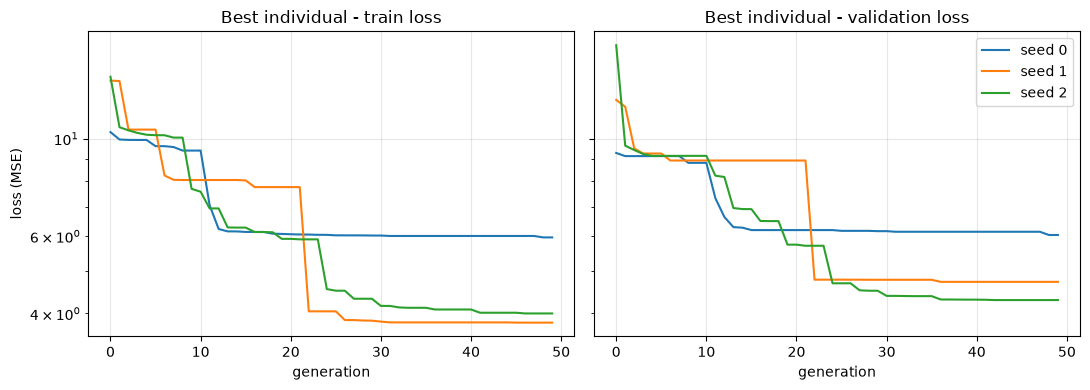

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for seed, l in log.groupby("random_state"):
    axs[0].plot(l["generation"], l["best_score"], label=f"seed {seed}")
    axs[1].plot(l["generation"], l["best_score_val"], label=f"seed {seed}")

axs[0].set_title("Best individual - train loss")
axs[1].set_title("Best individual - validation loss")
for ax in axs:
    ax.set_xlabel("generation")
    ax.set_yscale("log")
    ax.grid(alpha=0.3)
axs[0].set_ylabel("loss (MSE)")
axs[1].legend()
plt.tight_layout()

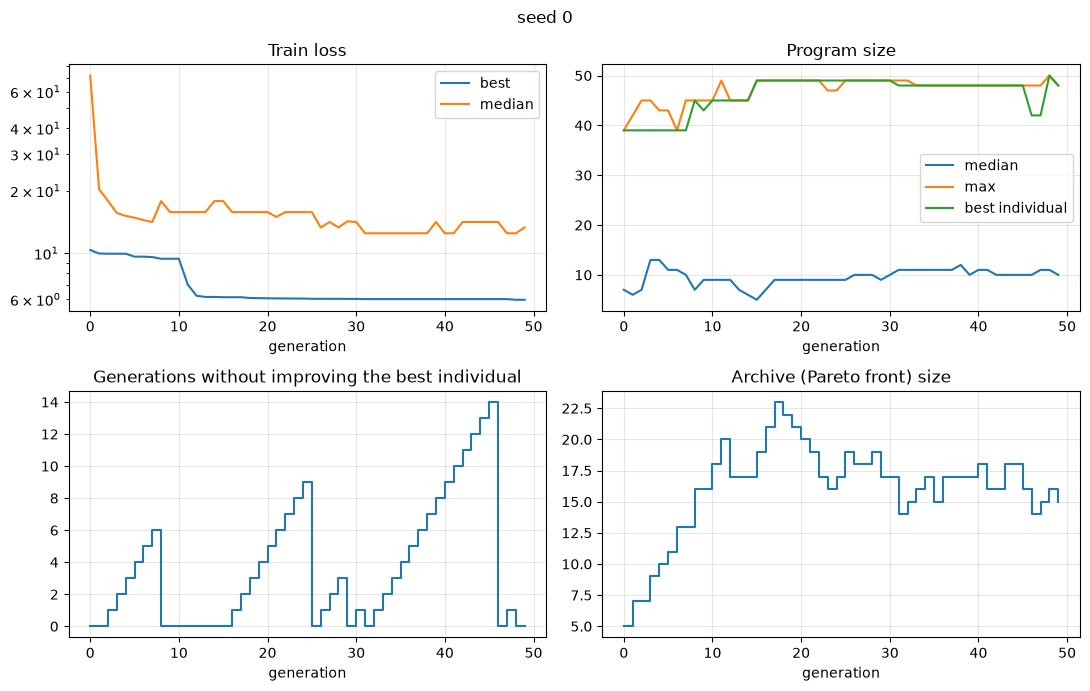

In [7]:
l = log[log["random_state"] == 0]
fig, axs = plt.subplots(2, 2, figsize=(11, 7))

axs[0, 0].plot(l["generation"], l["best_score"], label="best")
axs[0, 0].plot(l["generation"], l["med_score"], label="median")
axs[0, 0].set_yscale("log")
axs[0, 0].set_title("Train loss")
axs[0, 0].legend()

axs[0, 1].plot(l["generation"], l["med_size"], label="median")
axs[0, 1].plot(l["generation"], l["max_size"], label="max")
axs[0, 1].plot(l["generation"], l["best_size"], label="best individual")
axs[0, 1].set_title("Program size")
axs[0, 1].legend()

axs[1, 0].plot(l["generation"], l["stall_count"], drawstyle="steps-post")
axs[1, 0].set_title("Generations without improving the best individual")

axs[1, 1].plot(l["generation"], l["archive_size"], drawstyle="steps-post")
axs[1, 1].set_title("Archive (Pareto front) size")

for ax in axs.flat:
    ax.set_xlabel("generation")
    ax.grid(alpha=0.3)
fig.suptitle("seed 0")
plt.tight_layout()

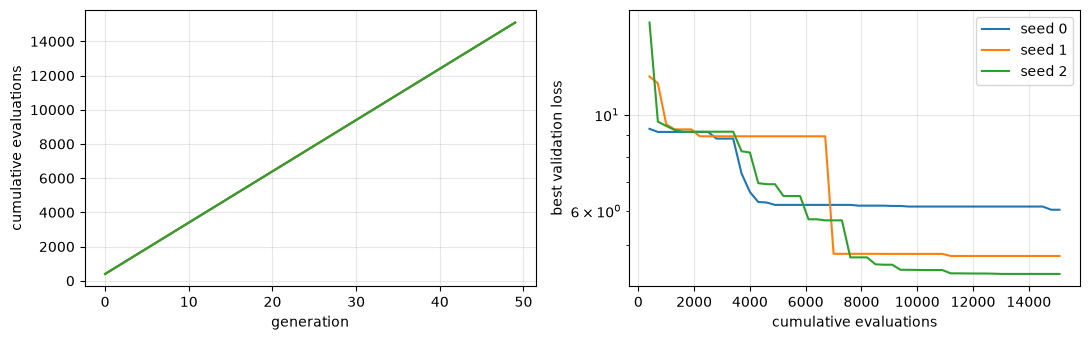

In [8]:
# cost of the search
fig, axs = plt.subplots(1, 2, figsize=(11, 3.5))
for seed, l in log.groupby("random_state"):
    axs[0].plot(l["generation"], l["n_evaluations"], label=f"seed {seed}")
    axs[1].plot(l["n_evaluations"], l["best_score_val"], label=f"seed {seed}")
axs[0].set_xlabel("generation")
axs[0].set_ylabel("cumulative evaluations")
axs[1].set_xlabel("cumulative evaluations")
axs[1].set_ylabel("best validation loss")
axs[1].set_yscale("log")
for ax in axs:
    ax.grid(alpha=0.3)
axs[1].legend()
plt.tight_layout()

## Best expression over the generations

The `best_model` column shows how the best individual changed. We keep only the
generations where it changed.

In [9]:
l = log[log["random_state"] == 0]
changes = l[l["best_model"] != l["best_model"].shift()]
changes[["generation", "best_score_val", "best_size", "best_model"]]

,generation,best_score_val,best_size,best_model
0,0,9.278577,39,"1.62*Add(0.32*Add(109.51*Div(109.30*x3,200.26*Add(225.90*x2,-788.44*Sqrtabs(-3332.07*x4))),31.95..."
1,1,9.127022,39,"1.62*Add(0.32*Add(67.72*Div(67.59*x3,302.11*Add(227.53*x2,-783.07*Sqrtabs(-3286.79*x4))),32.25*x..."
8,8,8.810316,45,"0.69*Add(0.43*Add(970.14*Div(48.11*x3,-381.89*Add(230.46*x2,-762.89*Sqrtabs(-3304.37*x4))),55.19..."
9,9,8.810287,43,"0.70*Add(23.25*Add(332.12*Div(16.47*x3,-2464.26*Add(231.03*x2,-763.86*Sqrtabs(-3312.69*x4))),x6)..."
10,10,8.810237,45,"0.68*Add(0.43*Add(965.64*Div(48.34*x3,-383.90*Add(230.41*x2,-762.89*Sqrtabs(-3302.95*x4))),54.92..."
11,11,7.319740,45,"0.68*Add(0.43*Add(2659.25*Div(16753.25*x0,3640.52*Add(185.45*x2,-421.66*Sqrtabs(-3207.36*x4))),5..."
12,12,6.632836,45,"0.67*Add(0.41*Add(1756.35*Div(11066.24*x0,5321.64*Add(185.13*x2,-422.40*Sqrtabs(-3218.61*x4))),5..."
13,13,6.288856,45,"0.68*Add(0.40*Add(1699.36*Div(10700.80*x0,5499.05*Add(185.11*x2,-422.43*Sqrtabs(-3219.07*x4))),5..."
14,14,6.271890,45,"0.36*Add(4.50*Add(-1149.91*Div(-5750.37*x0,11909.45*Add(185.11*x2,-422.35*Sqrtabs(-3220.11*x4)))..."
15,15,6.192916,49,"0.45*Add(0.22*Add(2058.68*Div(16604.21*x0,4962.30*Add(185.08*x2,-422.45*Sqrtabs(-3219.49*x4))),0..."


## Per-island statistics

columns: ['run_id', 'generation', 'island', 'n_individuals', 'best_score', 'best_score_val', 'med_score', 'med_score_val', 'med_size', 'med_complexity', 'max_size', 'max_complexity']


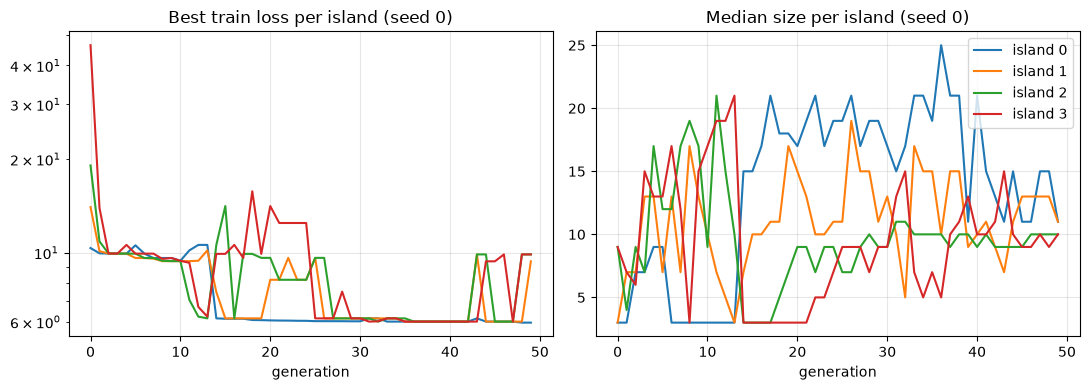

In [10]:
islands = pd.read_csv(LOGFILE + "_islands.csv")
print("columns:", list(islands.columns))

isl = islands[islands["run_id"] == runs.loc[runs["random_state"] == 0, "run_id"].iloc[0]]

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
for island, g in isl.groupby("island"):
    axs[0].plot(g["generation"], g["best_score"], label=f"island {island}")
    axs[1].plot(g["generation"], g["med_size"], label=f"island {island}")
axs[0].set_title("Best train loss per island (seed 0)")
axs[0].set_yscale("log")
axs[1].set_title("Median size per island (seed 0)")
for ax in axs:
    ax.set_xlabel("generation")
    ax.grid(alpha=0.3)
axs[1].legend()
plt.tight_layout()

## Final Pareto fronts

The CSV logs only keep the best individual. The whole front (extracted right before the last valid generation) is available from the
fitted estimator (`archive_`).

In [11]:
front = pd.DataFrame([
    {
        "size": ind.program.size(),
        "complexity": ind.program.linear_complexity(),
        "val_loss": ind.fitness.loss_v,
        "model": ind.program.get_model(),
    }
    for ind in estimators[0].archive_
]).sort_values("complexity")
front

,size,complexity,val_loss,model
0,1,2,97.703964,24.17
1,3,5,19.342838,4.60*x4
2,7,13,14.473068,"11.41*Add(0.37*x4,x6)"
3,10,20,12.181124,"6.69*Exp(Sub(0.21*x4,-0.63*x6))"
4,11,21,10.951211,"Sub(5.61*x4,Sub(-17.91*x6,-11.82*x0))"
5,11,25,10.312360,"Sub(-10.30,0.01*Mul(Sub(-338.44*x6,x1),x4))"
6,13,28,9.265789,"Sub(-0.03*x3,0.01*Mul(Sub(-380.14*x6,x1),x4))"
7,15,30,9.265786,"Sub(-0.03*x3,0.07*Mul(Sub(-42.68*x6,0.11*x1),x4))"
8,17,32,9.265783,"Sub(-0.03*x3,0.09*Mul(Sub(-55.68*x6,0.15*x1),0.61*x4))"
9,23,45,8.871875,"0.15*Sub(-1217.18,Mul(2.08*Add(Sub(-56.72*x6,1.17*x1),0.21*x3),Sub(x0,-0.02*x4)))"


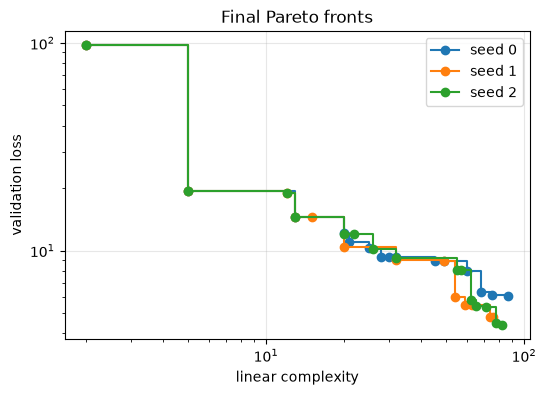

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
for seed, e in estimators.items():
    pts = sorted((i.program.linear_complexity(), i.fitness.loss_v) for i in e.archive_)
    ax.step(*zip(*pts), where="post", marker="o", label=f"seed {seed}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.set_xlabel("linear complexity")
ax.set_ylabel("validation loss")
ax.set_title("Final Pareto fronts")
ax.legend()
ax.grid(alpha=0.3)

## Simplifications

Each row of `_simplifications.csv` is one replacement made in an offspring:

- `constants`: a subtree with (almost) constant output was replaced by a constant;
- `inexact`: a subtree was replaced by a smaller one with (almost) the same output,
  found with locality-sensitive hashing. `distance` is the MSE between the predictions
  of the program before and after the replacement.

In [13]:
simp = pd.read_csv(LOGFILE + "_simplifications.csv")
print("columns:", list(simp.columns))
simp.groupby(["run_id", "simplifier"]).size().unstack(fill_value=0)

columns: ['run_id', 'generation', 'individual_id', 'simplifier', 'ret_type', 'original', 'replacement', 'distance']


simplifier,constants,inexact
run_id,,
20260923T121716.761-c517,244,102
20260923T121720.173-a13f,180,98
20260923T121723.647-be9d,175,114


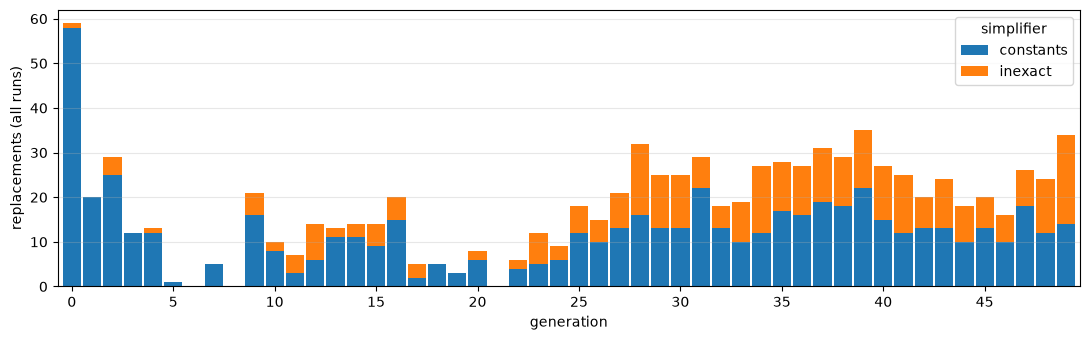

In [14]:
counts = simp.groupby(["generation", "simplifier"]).size().unstack(fill_value=0)
counts = counts.reindex(range(log["generation"].max() + 1), fill_value=0)
ax = counts.plot(kind="bar", stacked=True, figsize=(11, 3.5), width=0.9)
ax.set_ylabel("replacements (all runs)")
ax.set_xticks(range(0, len(counts), 5), labels=range(0, len(counts), 5), rotation=0)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()

### Some examples

The inexact replacements that removed the most (by expression length):

In [15]:
inexact = simp[simp["simplifier"] == "inexact"].copy()
inexact["saved_chars"] = inexact["original"].str.len() - inexact["replacement"].str.len()
inexact.sort_values("saved_chars", ascending=False)[
    ["generation", "individual_id", "original", "replacement", "distance"]
].head(10)

,generation,individual_id,original,replacement,distance
406,23,2404,"Add(620.09*Exp(-9071.97*Div(-9068.50*x0,-19514.49*x3)),2.01*Cos(0.96*Add(0.96*x3,9.61*x6)))","2.01*Cos(0.96*Add(0.96*x3,9.61*x6))",2.754639e-06
477,31,3281,"Add(0.01*Mul(0.02*x4,0.05*Add(-433.39*x6,0.05*x2)),-1.12*Sin(-46.28*x0))",-1.12*Sin(-46.28*x0),4.804618e-06
747,26,2754,"1.00*Sub(1.00*x2,1.14*Sub(3.65*x0,-1.01*Logabs(-0.63*x4)))","Sub(x2,x4)",4.830749e-06
593,46,4727,"Add(Mul(-0.00*Sub(0.00*x1,4.43*x6),0.00*x3),x0)",x0,1.637908e-06
618,49,5057,"1.87*Div(Sub(Sqrtabs(2.10*x0),0.01*x6),Add(1.74*x0,-1.23*x0))","Div(Logabs(x1),1.00)",1.941102e-06
377,2,368,"0.97*Add(0.70*Sqrtabs(0.37*x0),1.06*Add(1.12*x4,1.12*x4))","Add(1.22*x4,1.22*x4)",3.768802e-06
870,43,4428,"1.26*Sub(1.93*x4,3.17*Div(x2,-2.06*x1))",x4,4.058915e-06
634,0,157,"Add(-2373540.50*Cos(5477914.00*x4),-2411207.25*Sub(5827149.00*x4,110628.20*x1))","-2411207.25*Sub(5827149.00*x4,110628.20*x1)",1.877450e-16
61,11,1207,"0.95*Add(0.97*Div(0.97*x4,1.03*x0),0.95*Div(0.95*x3,1.05*x0))","2.13*Div(2.13*x3,0.31*x0)",4.574575e-08
843,39,4060,"0.81*Add(0.47*Mul(0.47*x3,0.13),0.73*x2)","Sub(x2,x4)",7.030044e-06


In [16]:
simp[simp["simplifier"] == "constants"][["generation", "original", "replacement"]].head(10)

,generation,original,replacement
0,0,"Exp(Mul(Add(Cos(x3),Add(x2,x6)),Sub(1.00,373.44*Sqrtabs(555.29*x4))))",0.00
1,0,"-2.98*Div(-2.92*x0,5.92*x0)",1.47
2,0,"0.13*Mul(0.06,0.19*x0)",0.00
3,0,"-0.23*Mul(-1.27,-0.23)",-0.07
4,0,-38.37*Sin(-5.00),-36.82
5,0,"Sub(x2,x2)",0.00
6,0,1.50*Sin(1.69),1.49
7,0,"2.51*Exp(Mul(Exp(x0),Mul(Mul(x1,x2),Sin(Logabs(x2)))))",0.00
8,0,12.85*Logabs(31326.93),133.03
9,0,"Sub(x2,x2)",0.00


The replaced subtrees are not identical: the inexact simplifier compares centered
predictions, so a replacement may differ by an offset or scale that the program's weights
absorb. `distance` records how little the predictions of the whole program changed.

## The simplification table

`_simplification_table` is a dump of every expression stored by the inexact simplifier
at the end of each run. Expressions sharing `(DataType, Plane, Key)` are candidates to
replace each other.

In [17]:
table = pd.read_csv(LOGFILE + "_simplification_table")
print("columns:", list(table.columns))
table.groupby(["run_id", "DataType"]).size().unstack(fill_value=0)

columns: ['run_id', 'DataType', 'Plane', 'Key', 'Tree']


DataType,ArrayB,ArrayF,ArrayI
run_id,,,
20260923T121716.761-c517,1,2758,3
20260923T121720.173-a13f,1,3062,3
20260923T121723.647-be9d,1,2619,3
